In [3]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

In [7]:
X = torch.linspace(-1, 1, 50).reshape(-1, 1); y = 2 * X + 1

model = nn.Linear(1 , 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

for step in range(200):
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    print(f"at step :{step} loss:{loss}")

    optimizer.step()
print(model.weight.item(), model.bias.item())

# single layer neural network in step loop

at step :0 loss:3.503678321838379
at step :1 loss:2.8388147354125977
at step :2 loss:2.333399772644043
at step :3 loss:1.9407354593276978
at step :4 loss:1.6295018196105957
at step :5 loss:1.3784115314483643
at step :6 loss:1.1727659702301025
at step :7 loss:1.0022259950637817
at step :8 loss:0.8593684434890747
at step :9 loss:0.7387436032295227
at step :10 loss:0.6362589597702026
at step :11 loss:0.54877108335495
at step :12 loss:0.4738146662712097
at step :13 loss:0.4094187915325165
at step :14 loss:0.35398179292678833
at step :15 loss:0.30618390440940857
at step :16 loss:0.2649252712726593
at step :17 loss:0.2292807400226593
at step :18 loss:0.19846700131893158
at step :19 loss:0.17181669175624847
at step :20 loss:0.1487593948841095
at step :21 loss:0.12880545854568481
at step :22 loss:0.11153392493724823
at step :23 loss:0.0965820848941803
at step :24 loss:0.08363702893257141
at step :25 loss:0.0724286139011383
at step :26 loss:0.06272321939468384
at step :27 loss:0.054318975657224

In [29]:
digits = load_digits()
X, y = digits.data, digits.target
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size = 0.25,
                                   random_state = 42, stratify= y)
sc = StandardScaler().fit(Xtr)
Xtr = torch.tensor(sc.transform(Xtr), dtype = torch.float32)
ytr = torch.tensor(ytr, dtype = torch.long)
Xte = torch.tensor(sc.transform(Xte), dtype=torch.float32)
yte = torch.tensor(yte, dtype = torch.long)

model = nn.Sequential(
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Linear(16,10),
)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.5)

loss_tensor = []
for epoch in range(100):
    pred = model(Xtr)
    loss = loss_fn(pred, ytr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_tensor.append(loss)
    print(f"epoch:{epoch} loss:{loss.mean()}")

with torch.no_grad():
    acc = (model(Xte).argmax(1) == yte).float().mean()


epoch:0 loss:2.323441982269287
epoch:1 loss:2.3032872676849365
epoch:2 loss:2.2859628200531006
epoch:3 loss:2.2692627906799316
epoch:4 loss:2.2516136169433594
epoch:5 loss:2.231234550476074
epoch:6 loss:2.2068071365356445
epoch:7 loss:2.177292585372925
epoch:8 loss:2.1414175033569336
epoch:9 loss:2.0972607135772705
epoch:10 loss:2.0435972213745117
epoch:11 loss:1.9795454740524292
epoch:12 loss:1.905789852142334
epoch:13 loss:1.8244447708129883
epoch:14 loss:1.737273931503296
epoch:15 loss:1.6455007791519165
epoch:16 loss:1.548454761505127
epoch:17 loss:1.4461770057678223
epoch:18 loss:1.340592861175537
epoch:19 loss:1.2362183332443237
epoch:20 loss:1.1373318433761597
epoch:21 loss:1.0443646907806396
epoch:22 loss:0.9549391865730286
epoch:23 loss:0.8680801391601562
epoch:24 loss:0.7847204208374023
epoch:25 loss:0.7079454660415649
epoch:26 loss:0.6400081515312195
epoch:27 loss:0.5813689827919006
epoch:28 loss:0.531088650226593
epoch:29 loss:0.4877680838108063
epoch:30 loss:0.450151354074

In [30]:
from matplotlib import pyplot as  plt
import numpy as np
loss_numpy = []

for i in loss_tensor:
    loss_numpy.append(i.detach().numpy())

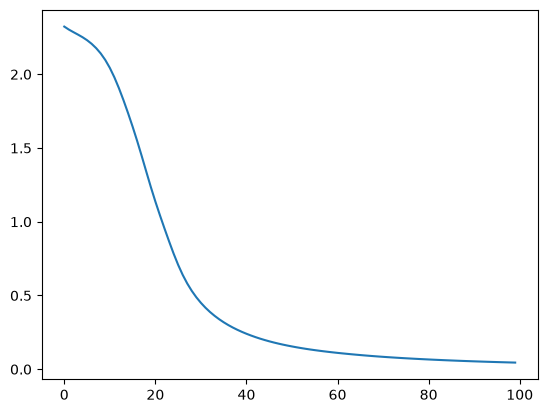

In [31]:
plt.plot(np.arange(100),loss_numpy)